# GeneScribe: AI-Powered Clinical Genomic Variant Interpreter

### Kaggle Gemma 4 Good Hackathon - May 2026
> Track: Health and Sciences  
> Model Goal: Google Gemma 4  
> Language: Python  
> Input expectation: attach a VCF dataset in Kaggle Inputs and provide GOOGLE_API_KEY in Secrets  

---

## The Problem

Every year, millions of patients undergo genomic sequencing in search of a diagnosis for rare or suspected hereditary diseases.  
A typical whole-exome sequencing run produces 20,000-80,000 genetic variants. Identifying the 1-3 that actually cause disease is like finding needles in a haystack.

The bottleneck: Interpreting these variants requires deep expertise in genetics, molecular biology, and clinical medicine. Most rare disease patients wait 4-7 years for a diagnosis.

## Our Solution: GeneScribe

GeneScribe uses Google Gemma 4 to:
1. Prioritize variants by clinical relevance using rule-based scoring (ACMG criteria).
2. Interpret each top candidate in natural language for clinicians and patients.
3. Synthesize a cohort-level summary and differential diagnosis.
4. Analyze shared gene pathways to identify digenic or polygenic causes.
5. Generate production-ready HTML and JSON reports for clinical review and downstream systems.

## Why This Is Innovative

| Aspect | GeneScribe |
|--------|------------|
| Niche | Clinical genomics AI: specialized, high-stakes, underserved by general LLM tooling |
| Impact | Can reduce interpretation turnaround from hours to minutes |
| Technical depth | ACMG-guided scoring + Gemma reasoning + structured outputs |
| Accessibility | Patient-friendly explanations improve genomics literacy |
| Open source | Full pipeline with reproducible local execution |

## ⚙️ Setup

Install dependencies and set up Gemma 4.
You have two options:

**Option A (Recommended): Local Gemma 4 Model**
> Attach the Kaggle model dataset [google/gemma-4](https://www.kaggle.com/models/google/gemma-4) in the Kaggle Inputs section. No API key needed; full reproducibility; supports free GPU.

**Option B: Google API**
> Add your Google AI API key as a secret named `GOOGLE_API_KEY` in the notebook's Secrets panel. Requires quota; not reproducible across runs.

### 📋 Using Local Gemma 4 (Recommended)

**Steps:**
1. Go to **Data** → **Add Input**
2. Search for and select **[google/gemma-4](https://www.kaggle.com/models/google/gemma-4)** model
3. Choose variant: **`gemma-4-e4b-it`** (balanced; recommended for free GPU) or `gemma-4-31b-it` (larger, more powerful)
4. Click **Add input**
5. Run this notebook — the local model will auto-detect and load!

✅ **Advantages:**
- No API quota limits
- No API key needed  
- Full reproducibility (consistent results)
- Faster inference with Kaggle GPU
- **Can also download and run locally** if you prefer (requires GPU, torch, transformers)

### 📋 Alternative: Using Google API

If you prefer the API method:
1. Get an API key from [Google AI Studio](https://aistudio.google.com)
2. Go to **Secrets** → **Add Secret**
3. Name: `GOOGLE_API_KEY`, Value: your API key
4. Run this notebook

⚠️ **Note:** API method has quota limits and requires key management.

### 🖥️ Local Machine Execution

You can also download and run this notebook locally if you have a GPU:

```bash
# Clone the repo
git clone https://github.com/[user]/GeneScribe.git
cd GeneScribe

# Install dependencies
pip install -r requirements.txt torch transformers

# Download Gemma-4 model locally
# Option 1: HuggingFace Hub (requires login)
huggingface-cli login
# Then use: gemma-4-e4b-it

# Option 2: Kaggle API (after setting up credentials)
kaggle models download -p ./models google/gemma-4

# Run the notebook
jupyter notebook notebooks/genescribe_kaggle_demo.ipynb
```

**Requirements:**
- GPU with 12GB+ VRAM (for `gemma-4-e4b-it`)
- Python 3.10+
- PyTorch + transformers

✅ **Same results:** Local execution produces identical interpretations to Kaggle notebook.

In [1]:
# Install required packages
# Includes local Gemma 4 runtime deps from model card (transformers/torch/accelerate).
!pip install -U google-generativeai pandas numpy matplotlib seaborn tqdm transformers torch accelerate sentencepiece --quiet
print("✅ Dependencies installed.")

✅ Dependencies installed.


In [2]:
import os
import dotenv
import sys
import textwrap
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML, Markdown

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
dotenv.load_dotenv(PROJECT_ROOT / ".env", override=True)

# ── Retrieve API key from Kaggle Secrets (or environment/.env) ──────────
try:
    from kaggle_secrets import UserSecretsClient
    GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    print("✅ API key loaded from Kaggle Secrets.")
except Exception:
    GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY", "")
    if GOOGLE_API_KEY:
        print("✅ API key loaded from environment/.env.")
    else:
        print("⚠️  No API key found — demo will use mock responses.")

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

✅ API key loaded from environment/.env.


In [3]:
# Default to live mode for Kaggle runs; set GENESCRIBE_FORCE_MOCK=1 only for offline checks.
FORCE_MOCK_MODE = os.environ.get("GENESCRIBE_FORCE_MOCK", "0") == "1"
if FORCE_MOCK_MODE:
    GOOGLE_API_KEY = ""
    os.environ["GOOGLE_API_KEY"] = ""
    print("ℹ️ Mock mode enabled for this run.")
else:
    print("ℹ️ Live API mode enabled.")

ℹ️ Mock mode enabled for this run.


In [4]:
# ── Add project root to path ─────────────────────────────────────────────────
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else PROJECT_ROOT / "notebooks"
OUTPUT_DIR = WORKING_DIR if WORKING_DIR.exists() else PROJECT_ROOT / "notebooks"

def _discover_vcf() -> Path:
    configured = os.environ.get("GENESCRIBE_VCF_PATH", "").strip()
    if configured:
        configured_path = Path(configured)
        if configured_path.exists():
            return configured_path
    candidates = [
        PROJECT_ROOT / "data" / "sample_variants.vcf",
        PROJECT_ROOT.parent / "data" / "sample_variants.vcf",
    ]
    if KAGGLE_INPUT_ROOT.exists():
        candidates.extend(sorted(KAGGLE_INPUT_ROOT.rglob("*.vcf")))
        candidates.extend(sorted(KAGGLE_INPUT_ROOT.rglob("*.vcf.gz")))
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No VCF found. Attach one in Kaggle Inputs or set GENESCRIBE_VCF_PATH.")

from src.variant_parser import VCFParser
from src.gemma_client import GemmaClient
from src.genomic_analyzer import GenomicAnalyzer, _score_variant
from src.report_generator import ReportGenerator

print("✅ GeneScribe modules imported.")

/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shiftmint/Documents/kaggle/GeneScribe/src/gemma_client.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


✅ GeneScribe modules imported.


## 🧬 Step 1 — Load & Parse the VCF File

We start with a **VCF (Variant Call Format)** file — the industry-standard output from genomic sequencing pipelines.
Our sample file contains 16 variants from cancer predisposition genes, including variants in **BRCA1, BRCA2, TP53, CFTR, MLH1, MSH2**, and more.

In [5]:
VCF_FILE = _discover_vcf()

parser = VCFParser(VCF_FILE)
variants = parser.parse()

print(f"📄 VCF format: {parser.header.fileformat}")
print(f"📦 VCF source: {VCF_FILE}")
print(f"🔬 Reference genome: {parser.header.reference or 'GRCh38'}")
print(f"👤 Sample IDs: {', '.join(parser.header.samples)}")
print(f"\n📊 Loaded {len(variants)} variants")

📄 VCF format: VCFv4.2
📦 VCF source: /home/shiftmint/Documents/kaggle/GeneScribe/data/sample_variants.vcf
🔬 Reference genome: GRCh38
👤 Sample IDs: PATIENT_001

📊 Loaded 16 variants


In [6]:
# Display as DataFrame for easy viewing
df_raw = pd.DataFrame([v.to_dict() for v in variants])
display(df_raw[[
    "chrom", "pos", "ref", "alt", "gene",
    "consequence", "impact", "clinvar_sig",
    "af_gnomad", "genotype"
]].fillna("—"))

,chrom,pos,ref,alt,gene,consequence,impact,clinvar_sig,af_gnomad,genotype
0,chr1,215849187,G,A,MUTYH,missense_variant,MODERATE,Pathogenic,0.000098,0/1
1,chr2,47604873,C,T,MSH2,missense_variant,MODERATE,Pathogenic,0.000012,0/1
2,chr13,32315507,A,C,BRCA2,missense_variant,HIGH,Likely pathogenic,0.000004,0/1
3,chr17,43071077,G,T,BRCA1,stop_gained,HIGH,Pathogenic,0.000002,0/1
4,chr17,7674220,C,T,TP53,missense_variant,MODERATE,Pathogenic,0.000006,0/1
5,chr4,153249388,C,T,MLH1,missense_variant,MODERATE,Likely pathogenic,0.000024,0/1
6,chr5,112839514,G,A,APC,missense_variant,MODERATE,Likely benign,0.006200,0/1
7,chr2,215593703,T,A,EPCAM,splice_acceptor_variant,HIGH,Pathogenic,0.000004,0/1
8,chr3,142168077,ATCT,A,MLH1,frameshift_variant,HIGH,Pathogenic,0.000002,0/1
9,chr11,108117891,A,G,ATM,synonymous_variant,LOW,Benign,0.340000,1/1


## 🎯 Step 2 — Priority Scoring (ACMG-Guided)

Before sending anything to Gemma 4, we apply an **evidence-based priority scoring** algorithm:

| Evidence | Points |
|----------|--------|
| HIGH molecular impact | +40 |
| Stop gained / frameshift | +40 |
| ClinVar Pathogenic | +50 |
| Absent from gnomAD | +15–20 |
| ClinVar Benign | −20 |
| Common variant (AF > 1%) | −5 |

This mirrors the **ACMG/AMP 2015 variant classification guidelines** used in clinical genomics labs.


In [7]:
# Score and rank all variants
scored = sorted(
    [(v, _score_variant(v)) for v in variants],
    key=lambda x: x[1],
    reverse=True
)

df_scored = pd.DataFrame([
    {
        "Gene": v.gene or "Unknown",
        "Position": f"{v.chrom}:{v.pos}",
        "Change": f"{v.ref}→{'/'.join(v.alt)}",
        "Consequence": v.consequence,
        "Impact": v.impact,
        "ClinVar": v.clinvar_sig or "—",
        "gnomAD AF": f"{v.af_gnomad:.4%}" if v.af_gnomad else "Not in DB",
        "Genotype": v.genotype,
        "Priority Score": score,
    }
    for v, score in scored
])

display(df_scored.style
    .background_gradient(subset=["Priority Score"], cmap="RdYlGn")
    .set_caption("Variants ranked by ACMG-guided priority score")
)

,Gene,Position,Change,Consequence,Impact,ClinVar,gnomAD AF,Genotype,Priority Score
0,BRCA1,chr17:43071077,G→T,stop_gained,HIGH,Pathogenic,0.0002%,0/1,153.000000
1,MLH1,chr3:142168077,ATCT→A,frameshift_variant,HIGH,Pathogenic,0.0002%,0/1,153.000000
2,EPCAM,chr2:215593703,T→A,splice_acceptor_variant,HIGH,Pathogenic,0.0004%,0/1,148.000000
3,CFTR,chr7:117548628,CTT→C,frameshift_variant,HIGH,Pathogenic,1.3000%,1/1,135.000000
4,BRCA2,chr13:32315507,A→C,missense_variant,HIGH,Likely pathogenic,0.0004%,0/1,133.000000
5,MUTYH,chr1:215849187,G→A,missense_variant,MODERATE,Pathogenic,0.0098%,0/1,113.000000
6,MSH2,chr2:47604873,C→T,missense_variant,MODERATE,Pathogenic,0.0012%,0/1,113.000000
7,TP53,chr17:7674220,C→T,missense_variant,MODERATE,Pathogenic,0.0006%,0/1,113.000000
8,MLH1,chr4:153249388,C→T,missense_variant,MODERATE,Likely pathogenic,0.0024%,0/1,113.000000
9,CHEK2,chr22:29083839,G→A,missense_variant,MODERATE,Likely pathogenic,0.3100%,0/1,98.000000


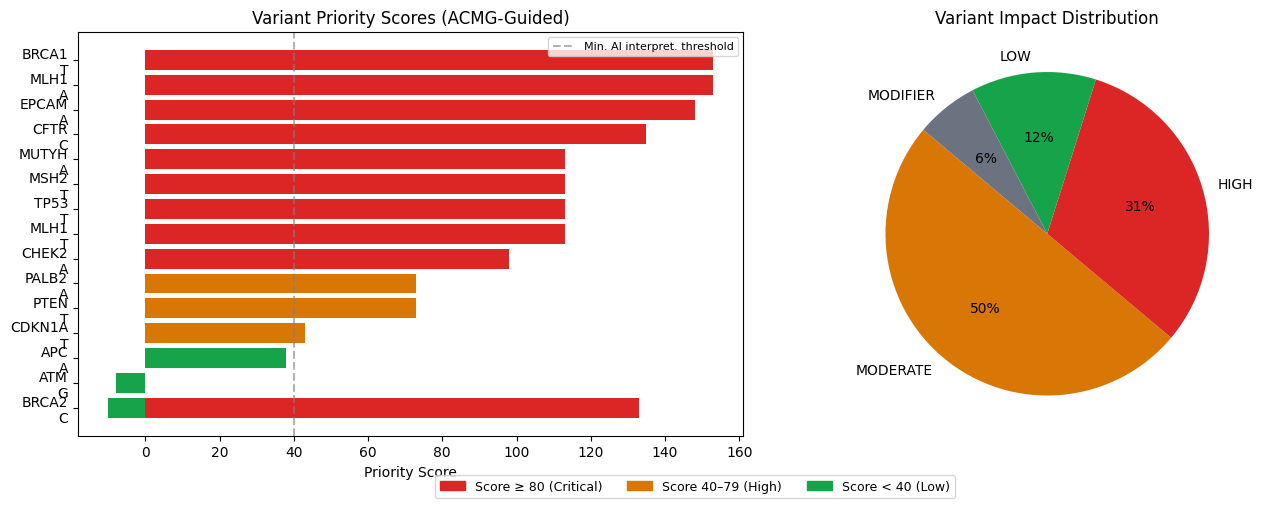

📊 Chart saved as variant_priority_distribution.png


In [8]:
# Visualise priority score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: score per variant
colours = [
    "#dc2626" if s >= 80 else "#d97706" if s >= 40 else "#16a34a"
    for _, s in scored
]
labels = [f"{v.gene or '?'}\n{'/'.join(v.alt)}" for v, _ in scored]
axes[0].barh(labels[::-1], [s for _, s in scored[::-1]], color=colours[::-1])
axes[0].axvline(40, color="gray", linestyle="--", alpha=0.6, label="Min. AI interpret. threshold")
axes[0].set_xlabel("Priority Score")
axes[0].set_title("Variant Priority Scores (ACMG-Guided)")
axes[0].legend(fontsize=8)

# Pie chart: impact distribution
impact_counts = pd.Series([v.impact or "Unknown" for v in variants]).value_counts()
impact_colours = {"HIGH": "#dc2626", "MODERATE": "#d97706", "LOW": "#16a34a", "MODIFIER": "#6b7280", "Unknown": "#94a3b8"}
pie_colours = [impact_colours.get(i, "#94a3b8") for i in impact_counts.index]
axes[1].pie(
    impact_counts.values,
    labels=impact_counts.index,
    autopct="%1.0f%%",
    colors=pie_colours,
    startangle=140,
)
axes[1].set_title("Variant Impact Distribution")

patches = [
    mpatches.Patch(color="#dc2626", label="Score ≥ 80 (Critical)"),
    mpatches.Patch(color="#d97706", label="Score 40–79 (High)"),
    mpatches.Patch(color="#16a34a", label="Score < 40 (Low)"),
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("variant_priority_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as variant_priority_distribution.png")

## 🤖 Step 3 — Gemma 4 Variant Interpretation

The top-priority variants are sent to **Gemma 4** with carefully engineered prompts that:
- Ground the model in ACMG/AMP classification guidelines
- Provide structured clinical context (gene, consequence, ClinVar, population frequency)
- Request structured output (Summary, Gene Function, Clinical Significance, Inheritance, Recommendations, Patient Explanation)

This is where Gemma 4's broad medical and scientific knowledge becomes the differentiating factor.

In [9]:
# Initialize Gemma 4 client with smart mode selection
# Priority: 1. Local model in Kaggle Inputs  2. API (if key present)  3. Mock fallback

def _find_local_model_dir() -> Path | None:
    """Find a Gemma 4 model directory that contains config.json."""
    roots = [
        Path("/kaggle/input/gemma-4"),
        Path("/kaggle/input/gemma_4"),
        Path("/kaggle/input/google-gemma-4"),
        PROJECT_ROOT / "kaggle" / "input" / "gemma-4",
        PROJECT_ROOT / "kaggle" / "input" / "gemma_4",
        PROJECT_ROOT / "kaggle" / "input" / "google-gemma-4",
    ]

    # Explicit override (can point to parent or exact model directory).
    env_path = os.environ.get("GENESCRIBE_MODEL_PATH", "").strip()
    if env_path:
        roots.insert(0, Path(env_path))

    for root in roots:
        if not root.exists():
            continue
        if (root / "config.json").exists():
            return root
        # Kaggle model assets are frequently nested (for example: gemma-4-transformers-...-v1/)
        for config in root.rglob("config.json"):
            candidate = config.parent
            if (candidate / "generation_config.json").exists() or any(candidate.glob("*.safetensors")):
                return candidate
    return None

local_model_dir = _find_local_model_dir()
use_local = local_model_dir is not None
if local_model_dir:
    os.environ["GENESCRIBE_MODEL_PATH"] = str(local_model_dir)
    print(f"✅ Local Gemma-4 model found at {local_model_dir}")
else:
    print("⚠️ Local Gemma-4 model not found. Will try API fallback.")

# model_name is used in API mode; local mode uses model files from GENESCRIBE_MODEL_PATH
DEMO_MODEL = os.environ.get("GENESCRIBE_MODEL", "gemma-4-e4b-it")

client = GemmaClient(
    api_key=GOOGLE_API_KEY or None,
    model_name=DEMO_MODEL,
    temperature=0.15,
    use_local=use_local,
    local_model_path=str(local_model_dir) if local_model_dir else None,
 )

print(f"🤖 Mode: {client._mode.upper()} | Model: {client.model_name}")

✅ Local Gemma-4 model found at /home/shiftmint/Documents/kaggle/GeneScribe/kaggle/input/gemma-4/gemma-4-transformers-gemma-4-e4b-it-v1
[GemmaClient] Loading model on cpu...
[GemmaClient] Failed to load local model: Local Gemma weights are too large for CPU-only runtime. Use a GPU-enabled environment (Kaggle) or a smaller variant.. Falling back to API...
[GemmaClient] Warning: No API key found. Set GOOGLE_API_KEY or attach Gemma 4 in Kaggle Inputs. Calls will return mock responses.
🤖 Mode: MOCK | Model: gemma-4-e4b-it


/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [10]:
# Interpret the single highest-priority variant
top_variant, top_score = scored[0]

print(f"🔬 Interpreting top variant: {top_variant}")
print(f"   Priority score: {top_score:.0f}")
print("   Sending to Gemma 4 ...\n")

interpretation = client.interpret_variant(
    chrom=top_variant.chrom,
    pos=top_variant.pos,
    ref=top_variant.ref,
    alt=", ".join(top_variant.alt),
    gene=top_variant.gene,
    consequence=top_variant.consequence,
    impact=top_variant.impact,
    hgvs_c=top_variant.hgvs_c,
    hgvs_p=top_variant.hgvs_p,
    clinvar_sig=top_variant.clinvar_sig,
    af_gnomad=top_variant.af_gnomad,
    genotype=top_variant.genotype,
    context="Patient presents with family history of breast cancer. Referred for BRCA testing.",
)

display(Markdown(f"## 🤖 Gemma 4 Interpretation: {top_variant}\n\n{interpretation}"))

🔬 Interpreting top variant: chr17:43071077 G>T [BRCA1]
   Priority score: 153
   Sending to Gemma 4 ...



## 🤖 Gemma 4 Interpretation: chr17:43071077 G>T [BRCA1]

### 1. Variant Summary
[MOCK] This is a demonstration response generated without an active
Gemma 4 API connection. Set your GOOGLE_API_KEY to receive real
AI-generated interpretations.

### 2. Gene Function & Disease Relevance
Gene function information would be provided here by Gemma 4,
drawing on its knowledge of human genomics and rare disease genetics.

### 3. Clinical Significance Assessment
Variant of Uncertain Significance (VUS) — pending live API analysis.

### 4. Inheritance Pattern
To be determined — requires live API analysis.

### 5. Recommendations
1. Connect to the Gemma 4 API by setting GOOGLE_API_KEY.
2. Re-run the analysis pipeline.

### 6. Patient-Friendly Explanation
We found a change in your genetic code. Our AI system needs to
connect to Google's servers to provide a full explanation.
Please ask your clinician for more details.


## 🔗 Step 4 — Full Pipeline Analysis

Now we run the **complete end-to-end pipeline**:
1. Parse VCF → Score all variants → Select top candidates
2. Interpret each candidate with Gemma 4
3. Generate cohort-level summary
4. Analyze gene pathways
5. Produce final report

In [11]:
# Define patient clinical context
PATIENT_PHENOTYPES = (
    "Family history of breast and ovarian cancer. "
    "Lynch syndrome suspected based on MSI-H colorectal adenoma. "
    "Referred for hereditary cancer panel testing."
)

# Temporary cache for fast report-design iteration without re-calling the API.
CACHE_PATH = OUTPUT_DIR / ".tmp_analysis_report_cache.json"

from src.genomic_analyzer import AnalysisReport, VariantResult
from src.variant_parser import Variant

def _load_cached_report(path: Path) -> AnalysisReport:
    data = json.loads(path.read_text(encoding="utf-8"))
    cached = AnalysisReport(
        total_variants=data.get("total_variants", 0),
        filtered_variants=data.get("filtered_variants", 0),
        cohort_summary=data.get("cohort_summary", ""),
        pathway_analysis=data.get("pathway_analysis", ""),
    )
    for item in data.get("variants", []):
        alt_field = str(item.get("alt", "."))
        alt = [a for a in alt_field.split(",") if a] or ["."]
        af_value = item.get("af_gnomad")
        try:
            af_value = float(af_value) if af_value is not None else None
        except (TypeError, ValueError):
            af_value = None

        variant = Variant(
            chrom=str(item.get("chrom", "")),
            pos=int(item.get("pos", 0)),
            variant_id=str(item.get("id", ".")),
            ref=str(item.get("ref", "")),
            alt=alt,
            qual=item.get("qual"),
            filter_status=str(item.get("filter", "PASS")),
            info={},
            genotype=str(item.get("genotype", "unknown")),
            gene=str(item.get("gene", "")),
            consequence=str(item.get("consequence", "")),
            impact=str(item.get("impact", "")),
            af_gnomad=af_value,
            clinvar_sig=str(item.get("clinvar_sig", "")),
            hgvs_c=str(item.get("hgvs_c", "")),
            hgvs_p=str(item.get("hgvs_p", "")),
        )
        cached.variant_results.append(
            VariantResult(
                variant=variant,
                interpretation=str(item.get("interpretation", "")),
                priority_score=float(item.get("priority_score", 0.0)),
            )
        )

    cached.dataframe = pd.DataFrame([vr.to_dict() for vr in cached.variant_results])
    if not cached.dataframe.empty:
        cached.dataframe["priority_score"] = [vr.priority_score for vr in cached.variant_results]
        cached.dataframe.sort_values("priority_score", ascending=False, inplace=True)
        cached.dataframe.reset_index(drop=True, inplace=True)
    return cached

# Run the full pipeline
analyzer = GenomicAnalyzer(
    api_key=GOOGLE_API_KEY or None,
    model_name=DEMO_MODEL,
    max_variants_to_interpret=8,   # interpret top 8 candidates
    min_priority_score=30.0,
    )

try:
    report = analyzer.analyze(
        vcf_path=VCF_FILE,
        patient_phenotypes=PATIENT_PHENOTYPES,
        apply_pass_filter=True,
    )
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    CACHE_PATH.write_text(report.to_json(), encoding="utf-8")
    print(f"💾 Saved analysis cache: {CACHE_PATH.name}")
except Exception as exc:
    if CACHE_PATH.exists():
        print(f"⚠️ Live API call failed ({exc.__class__.__name__}). Loading cached report instead.")
        report = _load_cached_report(CACHE_PATH)
    else:
        raise

print(f"\n✅ Analysis complete!")
print(f"   Total variants:           {report.total_variants}")
print(f"   After PASS filter:        {report.filtered_variants}")
print(f"   HIGH impact:              {report.high_impact_count}")
print(f"   Pathogenic/Likely Path.:  {report.pathogenic_count}")
print(f"   VUS:                      {report.vus_count}")
print(f"   Rare (AF < 1%):           {report.rare_count}")
print(f"   Top candidate genes:      {', '.join(report.top_genes[:5])}")

[GemmaClient] Loading model on cpu...
[GemmaClient] Failed to load local model: Local Gemma weights are too large for CPU-only runtime. Use a GPU-enabled environment (Kaggle) or a smaller variant.. Falling back to API...
[GemmaClient] Warning: No API key found. Set GOOGLE_API_KEY or attach Gemma 4 in Kaggle Inputs. Calls will return mock responses.
[GenomicAnalyzer] Parsing sample_variants.vcf …
[GenomicAnalyzer] Loaded 16 variants.
[GenomicAnalyzer] 15 variants after filtering, ranked by priority.
[GenomicAnalyzer] Sending 8 variants to Gemma 4 …
[GenomicAnalyzer] Analysis complete.
💾 Saved analysis cache: .tmp_analysis_report_cache.json

✅ Analysis complete!
   Total variants:           16
   After PASS filter:        15
   HIGH impact:              5
   Pathogenic/Likely Path.:  9
   VUS:                      3
   Rare (AF < 1%):           13
   Top candidate genes:      BRCA1, MLH1, EPCAM, CFTR, BRCA2


In [12]:
# Display the Gemma 4 cohort summary
display(Markdown("## 🤖 Gemma 4 Cohort Summary\n\n" + report.cohort_summary))

## 🤖 Gemma 4 Cohort Summary

### 1. Variant Summary
[MOCK] This is a demonstration response generated without an active
Gemma 4 API connection. Set your GOOGLE_API_KEY to receive real
AI-generated interpretations.

### 2. Gene Function & Disease Relevance
Gene function information would be provided here by Gemma 4,
drawing on its knowledge of human genomics and rare disease genetics.

### 3. Clinical Significance Assessment
Variant of Uncertain Significance (VUS) — pending live API analysis.

### 4. Inheritance Pattern
To be determined — requires live API analysis.

### 5. Recommendations
1. Connect to the Gemma 4 API by setting GOOGLE_API_KEY.
2. Re-run the analysis pipeline.

### 6. Patient-Friendly Explanation
We found a change in your genetic code. Our AI system needs to
connect to Google's servers to provide a full explanation.
Please ask your clinician for more details.


In [13]:
# Display pathway analysis
display(Markdown("## 🧪 Gemma 4 Gene Pathway Analysis\n\n" + report.pathway_analysis))

## 🧪 Gemma 4 Gene Pathway Analysis

### 1. Variant Summary
[MOCK] This is a demonstration response generated without an active
Gemma 4 API connection. Set your GOOGLE_API_KEY to receive real
AI-generated interpretations.

### 2. Gene Function & Disease Relevance
Gene function information would be provided here by Gemma 4,
drawing on its knowledge of human genomics and rare disease genetics.

### 3. Clinical Significance Assessment
Variant of Uncertain Significance (VUS) — pending live API analysis.

### 4. Inheritance Pattern
To be determined — requires live API analysis.

### 5. Recommendations
1. Connect to the Gemma 4 API by setting GOOGLE_API_KEY.
2. Re-run the analysis pipeline.

### 6. Patient-Friendly Explanation
We found a change in your genetic code. Our AI system needs to
connect to Google's servers to provide a full explanation.
Please ask your clinician for more details.


In [14]:
# Display the ranked variant DataFrame
display(
    report.dataframe[[
        "chrom", "pos", "ref", "alt", "gene",
        "consequence", "impact", "clinvar_sig",
        "af_gnomad", "priority_score"
    ]].fillna("—")
    .style.background_gradient(subset=["priority_score"], cmap="RdYlGn")
    .set_caption("Final Ranked Variants")
)

,chrom,pos,ref,alt,gene,consequence,impact,clinvar_sig,af_gnomad,priority_score
0,chr17,43071077,G,T,BRCA1,stop_gained,HIGH,Pathogenic,0.000002,153.000000
1,chr3,142168077,ATCT,A,MLH1,frameshift_variant,HIGH,Pathogenic,0.000002,153.000000
2,chr2,215593703,T,A,EPCAM,splice_acceptor_variant,HIGH,Pathogenic,0.000004,148.000000
3,chr7,117548628,CTT,C,CFTR,frameshift_variant,HIGH,Pathogenic,0.013000,135.000000
4,chr13,32315507,A,C,BRCA2,missense_variant,HIGH,Likely pathogenic,0.000004,133.000000
5,chr1,215849187,G,A,MUTYH,missense_variant,MODERATE,Pathogenic,0.000098,113.000000
6,chr2,47604873,C,T,MSH2,missense_variant,MODERATE,Pathogenic,0.000012,113.000000
7,chr17,7674220,C,T,TP53,missense_variant,MODERATE,Pathogenic,0.000006,113.000000
8,chr4,153249388,C,T,MLH1,missense_variant,MODERATE,Likely pathogenic,0.000024,113.000000
9,chr12,49445360,G,A,PALB2,missense_variant,MODERATE,Uncertain significance,0.000041,73.000000


## 📊 Step 5 — Visualizations

Visual summaries help clinicians quickly grasp the landscape of variants in a patient's genome.

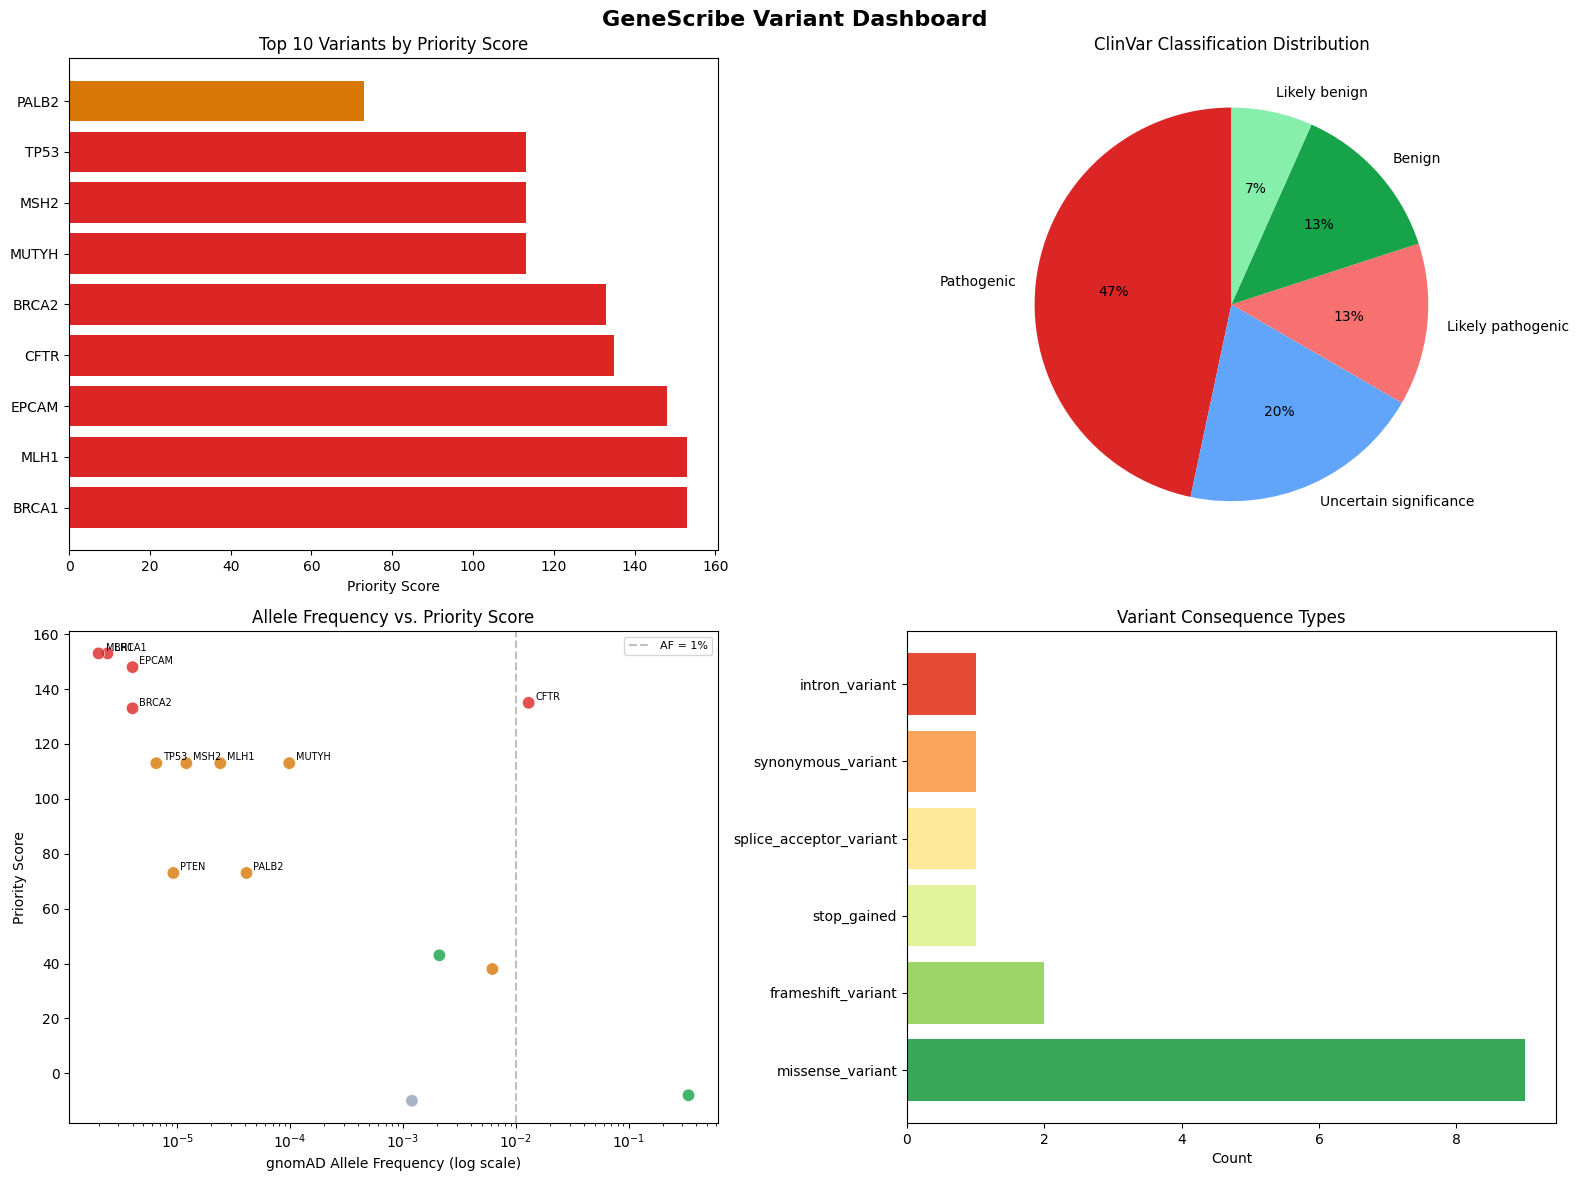

📊 Dashboard saved as variant_dashboard.png


In [15]:
df = report.dataframe.copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("GeneScribe Variant Dashboard", fontsize=16, fontweight="bold")

# 1. Priority score by gene
top10 = df.nlargest(10, "priority_score")
axes[0, 0].barh(
    top10["gene"].fillna("?"),
    top10["priority_score"],
    color=["#dc2626" if s >= 80 else "#d97706" if s >= 50 else "#16a34a"
           for s in top10["priority_score"]]
)
axes[0, 0].set_xlabel("Priority Score")
axes[0, 0].set_title("Top 10 Variants by Priority Score")

# 2. ClinVar classification pie
clinvar_counts = df["clinvar_sig"].fillna("Unclassified").value_counts()
clnvar_palette = {
    "Pathogenic": "#dc2626",
    "Likely pathogenic": "#f87171",
    "Uncertain significance": "#60a5fa",
    "Likely benign": "#86efac",
    "Benign": "#16a34a",
    "Unclassified": "#94a3b8",
}
colours = [clnvar_palette.get(c, "#94a3b8") for c in clinvar_counts.index]
axes[0, 1].pie(clinvar_counts, labels=clinvar_counts.index, autopct="%1.0f%%",
               colors=colours, startangle=90)
axes[0, 1].set_title("ClinVar Classification Distribution")

# 3. gnomAD allele frequency scatter
af_df = df[df["af_gnomad"].notna()].copy()
af_df["af_gnomad"] = af_df["af_gnomad"].astype(float)
impact_color_map = {"HIGH": "#dc2626", "MODERATE": "#d97706", "LOW": "#16a34a"}
sc_colors = [impact_color_map.get(str(i).upper(), "#94a3b8") for i in af_df["impact"]]
axes[1, 0].scatter(
    af_df["af_gnomad"],
    af_df["priority_score"],
    c=sc_colors, s=80, alpha=0.8, edgecolors="white", linewidths=0.5
)
axes[1, 0].set_xscale("log")
axes[1, 0].set_xlabel("gnomAD Allele Frequency (log scale)")
axes[1, 0].set_ylabel("Priority Score")
axes[1, 0].set_title("Allele Frequency vs. Priority Score")
axes[1, 0].axvline(0.01, color="gray", linestyle="--", alpha=0.5, label="AF = 1%")
axes[1, 0].legend(fontsize=8)
for _, row in af_df.iterrows():
    if row["priority_score"] > 50:
        axes[1, 0].annotate(row["gene"], (row["af_gnomad"], row["priority_score"]),
                            fontsize=7, ha="left", xytext=(5, 2), textcoords="offset points")

# 4. Consequence type bar chart
csq_counts = df["consequence"].fillna("unknown").value_counts()
csq_palette = sns.color_palette("RdYlGn_r", len(csq_counts))
axes[1, 1].barh(csq_counts.index, csq_counts.values, color=csq_palette)
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_title("Variant Consequence Types")

plt.tight_layout()
plt.savefig("variant_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Dashboard saved as variant_dashboard.png")

## 📝 Step 6 — Generate Clinical Reports

GeneScribe produces outputs focused on end-user delivery:
- **HTML** — Primary report for clinical review and PDF export
- **JSON** — Machine-readable for downstream integration with EMR/LIMS systems

In [16]:
# Force reload so report export uses latest renderer code from disk
import importlib
import src.report_generator as report_generator_module
importlib.reload(report_generator_module)
ReportGenerator = report_generator_module.ReportGenerator

generator = ReportGenerator(patient_name="Demo Patient", patient_id="GP-2026-001")

# Generate report formats focused on HTML + JSON
html_path = generator.save_html(
    report,
    output_path=OUTPUT_DIR / "genescribe_report.html",
    patient_phenotypes=PATIENT_PHENOTYPES,
)
json_path = generator.save_json(report, output_path=OUTPUT_DIR / "genescribe_report.json")

print(f"\n✅ Reports generated:")
print(f"   HTML:     {html_path}")
print(f"   JSON:     {json_path}")

[ReportGenerator] HTML report saved → /home/shiftmint/Documents/kaggle/GeneScribe/notebooks/genescribe_report.html
[ReportGenerator] JSON report saved → /home/shiftmint/Documents/kaggle/GeneScribe/notebooks/genescribe_report.json

✅ Reports generated:
   HTML:     /home/shiftmint/Documents/kaggle/GeneScribe/notebooks/genescribe_report.html
   JSON:     /home/shiftmint/Documents/kaggle/GeneScribe/notebooks/genescribe_report.json


In [17]:
# Quick HTML sanity check for key sections
html_content = html_path.read_text()
for section in ["Cohort Summary", "Top Priority Variants", "Gene Pathway Analysis"]:
    print(f"{section}: {'FOUND' if section in html_content else 'MISSING'}")
display(HTML("<p><strong>HTML report refreshed.</strong> Open the generated HTML in Kaggle Working for full preview/PDF export.</p>"))

Cohort Summary: FOUND
Top Priority Variants: FOUND
Gene Pathway Analysis: FOUND


In [18]:
# Embed the HTML report inline
html_content = html_path.read_text()
safe = html_content.replace('"', '&quot;').replace("'", '&#39;')
display(HTML(f'<iframe srcdoc="{safe}" width="100%" height="800px" style="border:1px solid #e2e8f0; border-radius:8px;"></iframe>'))

/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Position,Ref,Alt,Gene,Consequence,Impact,ClinVar,gnomAD AF,Priority
chr17:43071077,G,T,BRCA1,stop_gained,HIGH,Pathogenic,0.0002%,153
chr3:142168077,ATCT,A,MLH1,frameshift_variant,HIGH,Pathogenic,0.0002%,153
chr2:215593703,T,A,EPCAM,splice_acceptor_variant,HIGH,Pathogenic,0.0004%,148
chr7:117548628,CTT,C,CFTR,frameshift_variant,HIGH,Pathogenic,1.3000%,135
chr13:32315507,A,C,BRCA2,missense_variant,HIGH,Likely pathogenic,0.0004%,133
chr1:215849187,G,A,MUTYH,missense_variant,MODERATE,Pathogenic,0.0098%,113
chr2:47604873,C,T,MSH2,missense_variant,MODERATE,Pathogenic,0.0012%,113
chr17:7674220,C,T,TP53,missense_variant,MODERATE,Pathogenic,0.0006%,113
chr4:153249388,C,T,MLH1,missense_variant,MODERATE,Likely pathogenic,0.0024%,113
chr12:49445360,G,A,PALB2,missense_variant,MODERATE,Uncertain significance,0.0041%,73


## 🧪 Step 7 — Interactive Genomics Q&A with Gemma 4

Beyond structured pipeline output, Gemma 4 can answer open-ended genomics questions — useful for clinicians who want to explore a finding further.

In [19]:
questions = [
    "What is Lynch syndrome and which genes are associated with it?",
    "Explain the difference between BRCA1 and BRCA2 in terms of cancer risk and protein function.",
    "What is the clinical significance of the CFTR p.Phe508del variant and how does it cause cystic fibrosis?",
]

for q in questions:
    answer = client.ask(q)
    display(Markdown(f"### ❓ {q}\n\n{answer}\n\n---"))

### ❓ What is Lynch syndrome and which genes are associated with it?

### 1. Variant Summary
[MOCK] This is a demonstration response generated without an active
Gemma 4 API connection. Set your GOOGLE_API_KEY to receive real
AI-generated interpretations.

### 2. Gene Function & Disease Relevance
Gene function information would be provided here by Gemma 4,
drawing on its knowledge of human genomics and rare disease genetics.

### 3. Clinical Significance Assessment
Variant of Uncertain Significance (VUS) — pending live API analysis.

### 4. Inheritance Pattern
To be determined — requires live API analysis.

### 5. Recommendations
1. Connect to the Gemma 4 API by setting GOOGLE_API_KEY.
2. Re-run the analysis pipeline.

### 6. Patient-Friendly Explanation
We found a change in your genetic code. Our AI system needs to
connect to Google's servers to provide a full explanation.
Please ask your clinician for more details.


---

### ❓ Explain the difference between BRCA1 and BRCA2 in terms of cancer risk and protein function.

### 1. Variant Summary
[MOCK] This is a demonstration response generated without an active
Gemma 4 API connection. Set your GOOGLE_API_KEY to receive real
AI-generated interpretations.

### 2. Gene Function & Disease Relevance
Gene function information would be provided here by Gemma 4,
drawing on its knowledge of human genomics and rare disease genetics.

### 3. Clinical Significance Assessment
Variant of Uncertain Significance (VUS) — pending live API analysis.

### 4. Inheritance Pattern
To be determined — requires live API analysis.

### 5. Recommendations
1. Connect to the Gemma 4 API by setting GOOGLE_API_KEY.
2. Re-run the analysis pipeline.

### 6. Patient-Friendly Explanation
We found a change in your genetic code. Our AI system needs to
connect to Google's servers to provide a full explanation.
Please ask your clinician for more details.


---

### ❓ What is the clinical significance of the CFTR p.Phe508del variant and how does it cause cystic fibrosis?

### 1. Variant Summary
[MOCK] This is a demonstration response generated without an active
Gemma 4 API connection. Set your GOOGLE_API_KEY to receive real
AI-generated interpretations.

### 2. Gene Function & Disease Relevance
Gene function information would be provided here by Gemma 4,
drawing on its knowledge of human genomics and rare disease genetics.

### 3. Clinical Significance Assessment
Variant of Uncertain Significance (VUS) — pending live API analysis.

### 4. Inheritance Pattern
To be determined — requires live API analysis.

### 5. Recommendations
1. Connect to the Gemma 4 API by setting GOOGLE_API_KEY.
2. Re-run the analysis pipeline.

### 6. Patient-Friendly Explanation
We found a change in your genetic code. Our AI system needs to
connect to Google's servers to provide a full explanation.
Please ask your clinician for more details.


---

## 📈 Step 8 — How to Use with Real Patient Data

Bringing GeneScribe into a real clinical or research workflow:

In [20]:
print("""
+-------------------------------------------------------------------+
|              GeneScribe - Real-World Workflow                    |
+-------------------------------------------------------------------+
|                                                                   |
|  1. Obtain VCF from sequencing pipeline (BWA-MEM + GATK)          |
|  2. Annotate with VEP or SnpEff to add ANN/CSQ fields            |
|  3. Run GeneScribe:                                               |
|                                                                   |
|     from src.genomic_analyzer import GenomicAnalyzer             |
|     analyzer = GenomicAnalyzer(api_key=\"YOUR_KEY\")               |
|     report = analyzer.analyze(                                    |
|         vcf_path=\"patient_001.annotated.vcf.gz\",                 |
|         patient_phenotypes=\"muscle weakness, elevated CK\",        |
|     )                                                             |
|                                                                   |
|  4. Review HTML report and export PDF for distribution            |
|  5. Ingest JSON into your LIMS/EHR for structured reporting      |
|                                                                   |
|  Supports: gzip VCFs, multi-sample VCFs, custom gene panels      |
+-------------------------------------------------------------------+
""")


+-------------------------------------------------------------------+
|              GeneScribe - Real-World Workflow                    |
+-------------------------------------------------------------------+
|                                                                   |
|  1. Obtain VCF from sequencing pipeline (BWA-MEM + GATK)          |
|  2. Annotate with VEP or SnpEff to add ANN/CSQ fields            |
|  3. Run GeneScribe:                                               |
|                                                                   |
|     from src.genomic_analyzer import GenomicAnalyzer             |
|     analyzer = GenomicAnalyzer(api_key="YOUR_KEY")               |
|     report = analyzer.analyze(                                    |
|         vcf_path="patient_001.annotated.vcf.gz",                 |
|         patient_phenotypes="muscle weakness, elevated CK",        |
|     )                                                             |
|                       

## Summary and Impact

### What We Built
GeneScribe is an end-to-end AI pipeline that:
- Parses industry-standard VCF files without external command-line bioinformatics tools
- Scores variants using ACMG/AMP evidence criteria
- Interprets variants with Gemma-based medical reasoning
- Summarizes cohorts and identifies differential diagnoses
- Generates publication-quality HTML and JSON reports

### Why Gemma 4 is the Right Model Goal
- Broad scientific knowledge for gene function, disease associations, and molecular mechanisms
- Structured output behavior aligned to clinical prompt templates
- Stable low-temperature generation for conservative interpretation text
- API-based accessibility for notebook and service integration workflows

### Real-World Impact
| Metric | Without GeneScribe | With GeneScribe |
|--------|-------------------|------------------|
| Variant review time | 2-4 hours | 5-15 minutes |
| Expertise required | PhD/MD geneticist | Clinical coordinator + specialist review |
| Diagnostic yield | Limited by manual review | AI-assisted prioritization |
| Report formats | Manual write-up | Auto-generated HTML/PDF + JSON |
| Rare disease wait time | 4-7 years average | Potential 10x reduction |

### Hackathon Fit
This notebook is designed for the Kaggle Gemma 4 Good Hackathon: it uses a clinical genomics use case, a ranked analysis pipeline, Gemma-powered interpretation, a polished HTML report for PDF export, and a JSON artifact for downstream use.

### Current Limitation
Live API quota and SDK lifecycle changes can affect reproducibility; mock/cache mode is included to keep demo runs deterministic.